<a href="https://colab.research.google.com/github/IDI-RASIDI/1320123009-data-mining/blob/main/Segmentasi_Pelanggan_Mall_Tugas_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


print("Libraries imported successfully!")

Libraries imported successfully!


In [32]:
data = pd.read_csv('mall_Customers.csv')
print("Data shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Data shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [33]:
print("\nData info:")
print(data.info())
print("\nDescriptive statistics:")
print(data.describe())


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Descriptive statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750

##1. Exploratory Data Analysis (EDA)

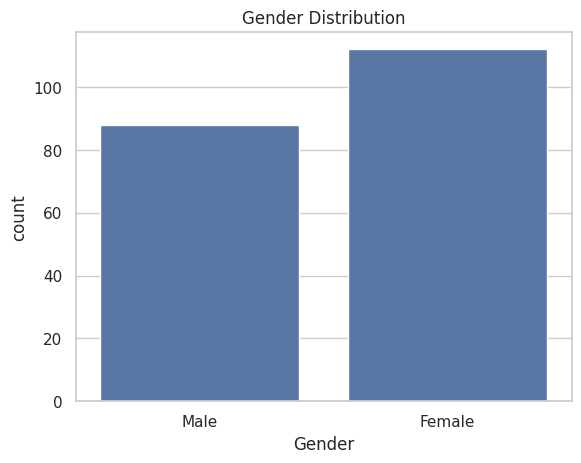

In [37]:
sns.countplot(x="Gender", data=data)
plt.title("Gender Distribution")
plt.show()

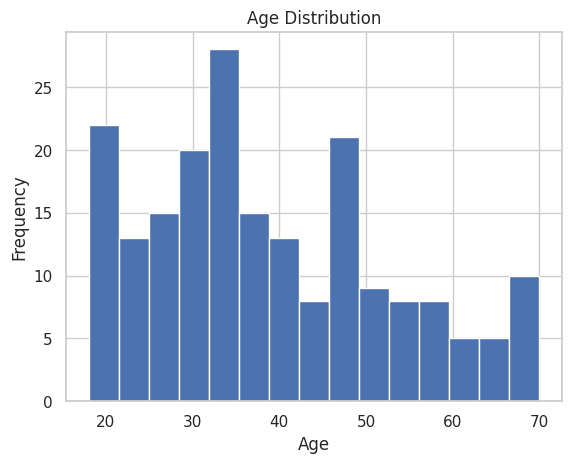

In [41]:
plt.hist(data["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

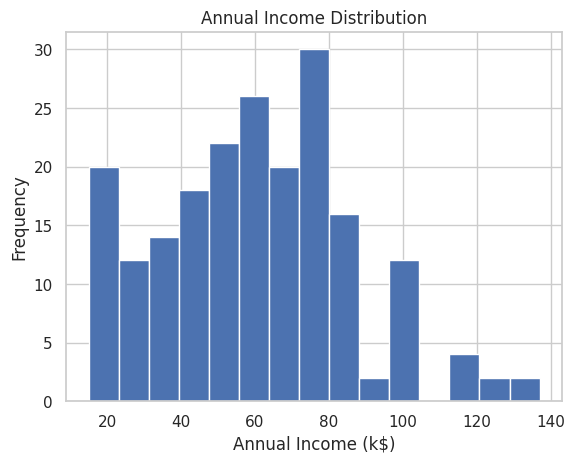

In [42]:
plt.hist(data["Annual Income (k$)"], bins=15)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

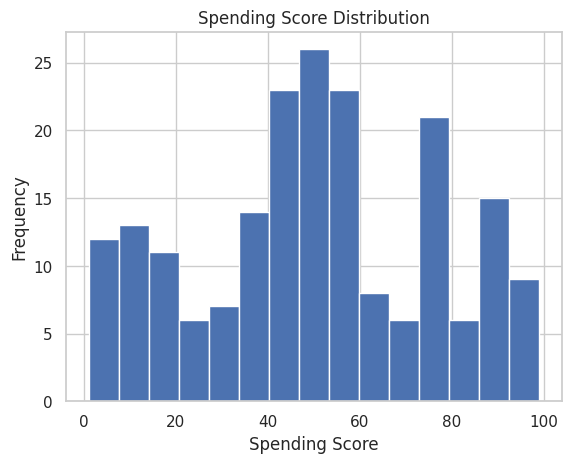

In [43]:
plt.hist(data["Spending Score (1-100)"], bins=15)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

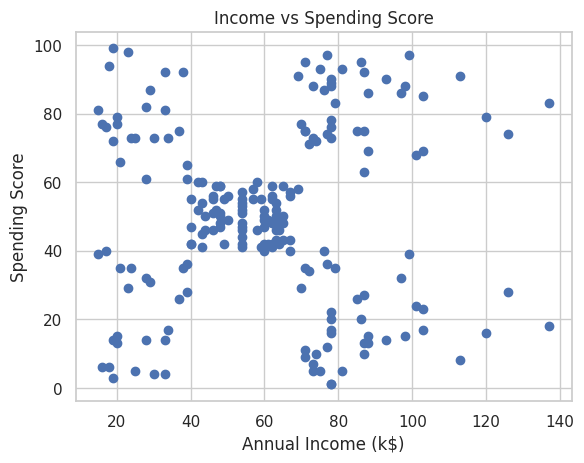

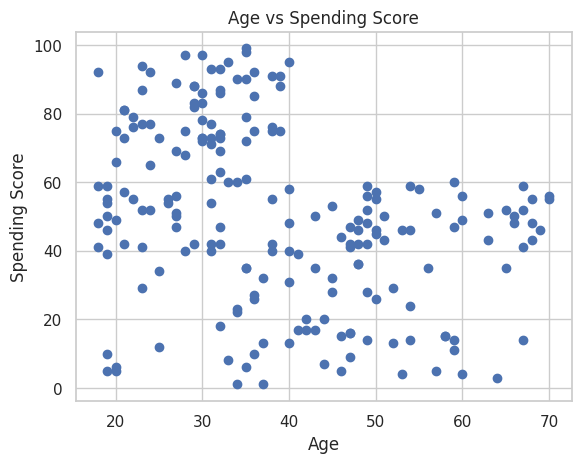

In [47]:
plt.scatter(data["Annual Income (k$)"], data["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()
plt.scatter(data["Age"], data["Spending Score (1-100)"])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

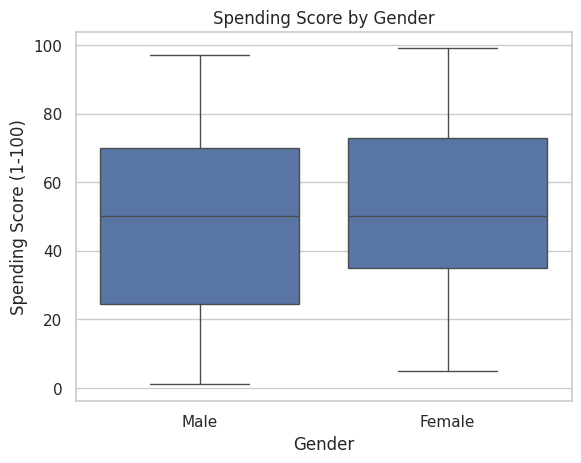

In [48]:
sns.boxplot(x="Gender", y="Spending Score (1-100)", data=data)
plt.title("Spending Score by Gender")
plt.show()

## 2. CLUSTERING

In [53]:
X = data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

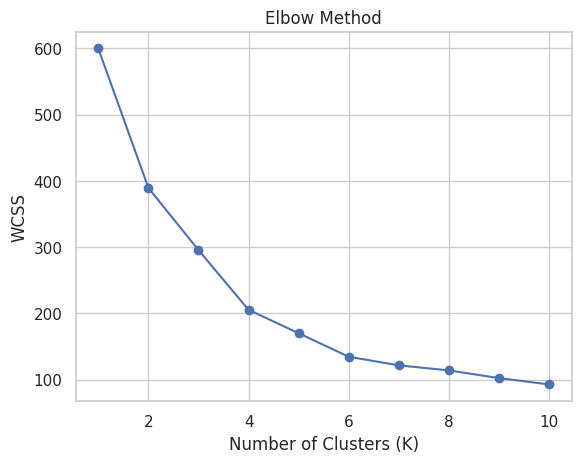

In [51]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [65]:
kmeans = KMeans(n_clusters=5, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)

data["Cluster"].value_counts()

,count
Cluster,
0,58
3,45
1,40
4,31
2,26


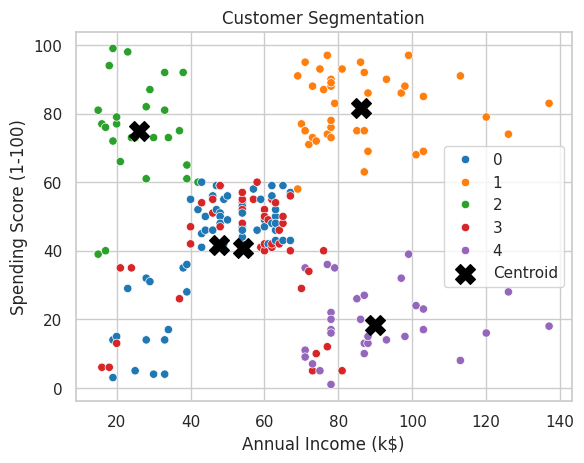

In [66]:
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    data=data,
    palette="tab10"
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,1],
    centroids[:,2],
    c="black",
    s=200,
    marker="X",
    label="Centroid"
)

plt.title("Customer Segmentation")
plt.legend()
plt.show()

## 3. INTERPRETASI

In [74]:
cluster_summary = data.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

cluster_summary


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


## 4. EVALUASI

In [75]:
data.groupby("Cluster")["Gender"].value_counts()


Cluster  Gender
0        Female    33
         Male      25
1        Female    22
         Male      18
2        Female    15
         Male      11
3        Female    27
         Male      18
4        Male      16
         Female    15
Name: count, dtype: int64

In [77]:
score = silhouette_score(X_scaled, data["Cluster"])
print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.408
